In [1]:
import sys                                                                                                                                                                                                        
sys.path.insert(0, '/home/svu/e1498138/emri_search/work')                                                                                                                                                   
                                                                                                                                                                                                                    
from GWfuncs_noise import GravWaveAnalysis, build_waveform_response                                                                                                                                                 
from loglike_timemax_noise import LogLike                                                                                                                                                                           
import numpy as np                                                                                                                                                                                                        
import cupy as cp

In [23]:
use_gpu=True                                                                                                                                       
T = 12/12        # years                 
dt = 5       # seconds

# Source parameters
m1 = 1e6
m2 = 1e1
a = 0.7
p0 = 8
e0 = 0.4
xI0 = 1.0
dist = 9 # 9  # Gpc
qS = np.pi
phiS = 0.
qK =  0.
phiK = 0.
Phi_phi0 = 0.4
Phi_theta0 = 0.0
Phi_r0 = 0.5                                                                                                                           
                                                                                                                                                                                                                                                                                                                                                    
                                        
waveform_response = build_waveform_response(T=T, dt=dt, use_gpu=use_gpu,tdi_gen=1)                                                                                                    
         

In [24]:
params=[m1,m2,a,p0,e0,xI0,dist,qS,phiS,qK,phiK,Phi_phi0,Phi_theta0,Phi_r0]

In [25]:
# n-indexed mode selection parameters
n_vals = np.arange(-1,6)  # n from -1 to 5
ell = 2  # quadrupole only

In [26]:
gwf = GravWaveAnalysis(T=T, dt=dt, use_gpu=True,tdi_gen=1)

In [27]:
# gwf_1yr = GravWaveAnalysis(T=1, dt=dt, use_gpu=True,tdi_gen=1)

In [28]:


loglike_obj= LogLike(                                                                                                                                                                                                       
    params=params,                                                                                                                                                                                                  
    waveform_response=waveform_response,                                                                                                                                                                            
    gwf=gwf,                                                                                                                                                                                                      
    add_noise=True,
    verbose=True,
    ell=ell,                                                                                                                                                                                                          
    n_vals=n_vals,
    M_mode=None,                                                                                                                                                                                                    
)  

[INFO] Added colored noise with seed=0
Delta_T for mode selection: 6311.629952709119 seconds
Selected modes (l,m,n): [[(2, 0, -1), (2, 1, -1), (2, 2, -1), (2, -1, -1), (2, -2, -1)], [(2, 0, 0), (2, 1, 0), (2, 2, 0), (2, -1, 0), (2, -2, 0)], [(2, 0, 1), (2, 1, 1), (2, 2, 1), (2, -1, 1), (2, -2, 1)], [(2, 0, 2), (2, 1, 2), (2, 2, 2), (2, -1, 2), (2, -2, 2)], [(2, 0, 3), (2, 1, 3), (2, 2, 3), (2, -1, 3), (2, -2, 3)], [(2, 0, 4), (2, 1, 4), (2, 2, 4), (2, -1, 4), (2, -2, 4)], [(2, 0, 5), (2, 1, 5), (2, 2, 5), (2, -1, 5), (2, -2, 5)]]
Selected modes: [[(2, 0, -1), (2, 1, -1), (2, 2, -1), (2, -1, -1), (2, -2, -1)], [(2, 0, 0), (2, 1, 0), (2, 2, 0), (2, -1, 0), (2, -2, 0)], [(2, 0, 1), (2, 1, 1), (2, 2, 1), (2, -1, 1), (2, -2, 1)], [(2, 0, 2), (2, 1, 2), (2, 2, 2), (2, -1, 2), (2, -2, 2)], [(2, 0, 3), (2, 1, 3), (2, 2, 3), (2, -1, 3), (2, -2, 3)], [(2, 0, 4), (2, 1, 4), (2, 2, 4), (2, -1, 4), (2, -2, 4)], [(2, 0, 5), (2, 1, 5), (2, 2, 5), (2, -1, 5), (2, -2, 5)]]
Flattened modes: [(2, 0, -1),

In [29]:
loglike_obj.signal

array([[ 2.29037824e-21, -5.96831485e-21,  1.52055623e-20, ...,
         8.94321381e-21, -5.56764019e-21,  3.35656256e-21],
       [ 1.27927097e-21, -1.87985533e-21,  1.62884555e-21, ...,
        -1.40448937e-20,  8.05921996e-21, -9.80704172e-21],
       [-1.10100941e-21,  1.19570151e-20, -1.61856432e-20, ...,
        -2.16018325e-21, -7.88098485e-21,  7.26155734e-21]])

In [30]:
%%time
#loglike at true param
logl_true=loglike_obj(params)
print(logl_true)

Waveform amplitudes (time-maximized):
  Mode 0: <hf|hf>_timemax=14.82, rho=3.85
  Mode 1: <hf|hf>_timemax=69.2, rho=8.318
  Mode 2: <hf|hf>_timemax=151.5, rho=12.31
  Mode 3: <hf|hf>_timemax=89.89, rho=9.481
  Mode 4: <hf|hf>_timemax=32.59, rho=5.709
  Mode 5: <hf|hf>_timemax=9.266, rho=3.044
  Mode 6: <hf|hf>_timemax=2.281, rho=1.51
rho_m: [ 3.85004206  8.31836569 12.3093568   9.48114802  5.70881291  3.04393099
  1.51043857]
Dominant mode index: 2, rho: 12.31
beta=0.01882, rho_dom_M=12.31, rho_tot=20.45
X_scalar (time-maximized): 21.02
Time-maximized Log-likelihood: 18.8748
18.874832516235234
CPU times: user 663 ms, sys: 20.8 ms, total: 683 ms
Wall time: 708 ms


In [31]:
params_perturbed = list(params)                                                                                                                                                                                     
params_perturbed[0] *= 1.01                                                                                                                                                                                         
logl_perturbed = loglike_obj(params_perturbed)                                                                                                                                                                               
print(logl_perturbed)

Waveform amplitudes (time-maximized):
  Mode 0: <hf|hf>_timemax=13.42, rho=3.663
  Mode 1: <hf|hf>_timemax=62.92, rho=7.932
  Mode 2: <hf|hf>_timemax=145.2, rho=12.05
  Mode 3: <hf|hf>_timemax=88.69, rho=9.417
  Mode 4: <hf|hf>_timemax=32.69, rho=5.717
  Mode 5: <hf|hf>_timemax=9.366, rho=3.06
  Mode 6: <hf|hf>_timemax=2.319, rho=1.523
rho_m: [ 3.66285393  7.93247647 12.0499577   9.41746202  5.71744064  3.06041284
  1.52277501]
Dominant mode index: 2, rho: 12.05
beta=0.01944, rho_dom_M=12.05, rho_tot=20.03
X_scalar (time-maximized): 5.261
Time-maximized Log-likelihood: 0.974704
0.9747038223333638


In [32]:

def logden_tm(params):
    logm1, logm2, a, p0, e0 = params
    return float(loglike_obj(np.array([10**logm1, 10**logm2, a, p0, e0,
                                    xI0, dist, qS, phiS, qK, phiK,
                                    Phi_phi0, Phi_theta0, Phi_r0])))

In [33]:
param_true = np.array([np.log10(m1), np.log10(m2), a, p0, e0])


In [34]:
# Sanity check at true params
print(logden_tm(param_true))

Waveform amplitudes (time-maximized):
  Mode 0: <hf|hf>_timemax=14.82, rho=3.85
  Mode 1: <hf|hf>_timemax=69.2, rho=8.318
  Mode 2: <hf|hf>_timemax=151.5, rho=12.31
  Mode 3: <hf|hf>_timemax=89.89, rho=9.481
  Mode 4: <hf|hf>_timemax=32.59, rho=5.709
  Mode 5: <hf|hf>_timemax=9.266, rho=3.044
  Mode 6: <hf|hf>_timemax=2.281, rho=1.51
rho_m: [ 3.85004206  8.31836569 12.3093568   9.48114802  5.70881291  3.04393099
  1.51043857]
Dominant mode index: 2, rho: 12.31
beta=0.01882, rho_dom_M=12.31, rho_tot=20.45
X_scalar (time-maximized): 21.02
Time-maximized Log-likelihood: 18.8748
18.874832516235234


In [35]:
# # Sweep over logm2
# param_idx = 1  # logm2
# # param_secondary = np.array([6.29332246, 0.97236086, 0.3347499, 10.18644061, 0.34722833])

# param_range = np.sort(np.append(np.linspace(0.99, 1.01, 200), param_true[param_idx]))

# f_stats_tm   = np.zeros(len(param_range))
# # f_stats_pm   = np.zeros(len(param_range))
# # f_stats_pure = np.zeros(len(param_range))
# # f_stats_tmX = np.zeros(len(param_range))
# # X_pure = np.zeros(len(param_range))
# X_tm = np.zeros(len(param_range))
# X_tpm = np.zeros(len(param_range))
# X_sc = np.zeros(len(param_range))


# for i, val in enumerate(param_range):

#     p = param_true.copy()
#     p[param_idx] = val
#     # f_stats_tm[i]   = logden_tm(p)
#     # f_stats_pm[i]   = logden_pm(p)
#     # f_stats_pure[i] = logden_pure(p)
#     # f_stats_tmX[i] = logden_tmX(p)

#     # X only (no chi_sq)
#     logm1, logm2, a_i, p0_i, e0_i = p
#     h = gwf.xp.array(waveform_response(
#         10**logm1, 10**logm2, a_i, p0_i, e0_i,
#         xI0, dist, qS, phiS, qK, phiK,
#         Phi_phi0, Phi_theta0, Phi_r0, T=T, dt=dt,
#     ))
#     h_fft_r = gwf.freq_wave(h)
#     rho_h   = float(gwf.xp.sqrt(gwf.inner(h_fft_r, h_fft_r)))
#     # X_pure[i] = float(gwf.inner(loglike_obj.signal_fft, h_fft_r, return_complex=False)) / rho_h
#     # X_tm[i] = float(gwf.inner_timemax(loglike_obj.signal, h,phasemax=False)) / rho_h
#     # X_tpm[i] = float(gwf.inner_timemax(loglike_obj.signal, h,phasemax=True)) / rho_h
#     X_sc[i] = float(gwf.SNR_semicoherent(loglike_obj.signal, h, N_seg=12))

In [36]:
print('Initializing loglike_pure...')
params_star = [m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]

import loglike_pure_noise
loglike_p = loglike_pure_noise.LogLike(
    params=params_star,
    waveform_response=waveform_response,
    gwf=gwf,
    add_noise=True,
    verbose=False,
    ell=ell, n_vals=n_vals, M_mode=None,
)

Initializing loglike_pure...


In [37]:
def logden_pure(params):
    logm1, logm2, a, p0, e0 = params
    return float(loglike_p(np.array([10**logm1, 10**logm2, a, p0, e0,
                                    xI0, dist, qS, phiS, qK, phiK,
                                    Phi_phi0, Phi_theta0, Phi_r0])))

In [44]:
# Sweep over logm2
param_idx = 1  # logm2
# param_secondary = np.array([6.29332246, 0.97236086, 0.3347499, 10.18644061, 0.34722833])

param_range = np.sort(np.append(np.linspace(0.975, 1.025, 100), param_true[param_idx]))

f_stats_tm   = np.zeros(len(param_range))
# f_stats_pm   = np.zeros(len(param_range))
f_stats_pure = np.zeros(len(param_range))
# f_stats_tmX = np.zeros(len(param_range))
# X_pure = np.zeros(len(param_range))
X_tm = np.zeros(len(param_range))
X_tpm = np.zeros(len(param_range))
Sfour = np.zeros(len(param_range))
Ssix = np.zeros(len(param_range))
Stwelve = np.zeros(len(param_range))
Ssixteen = np.zeros(len(param_range))
Sp= np.zeros(len(param_range))

for i, val in enumerate(param_range):

    p = param_true.copy()
    p[param_idx] = val
    f_stats_tm[i]   = logden_tm(p)
    # f_stats_pm[i]   = logden_pm(p)
    # f_stats_pure[i] = logden_pure(p)
    # f_stats_tmX[i] = logden_tmX(p)

    # X only (no chi_sq)
    logm1, logm2, a_i, p0_i, e0_i = p
    h = gwf.xp.array(waveform_response(
        10**logm1, 10**logm2, a_i, p0_i, e0_i,
        xI0, dist, qS, phiS, qK, phiK,
        Phi_phi0, Phi_theta0, Phi_r0, T=T, dt=dt,
    ))
    h_fft_r = gwf.freq_wave(h)
    rho_h   = float(gwf.xp.sqrt(gwf.inner(h_fft_r, h_fft_r)))
    # X_pure[i] = float(gwf.inner(loglike_obj.signal_fft, h_fft_r, return_complex=False)) / rho_h
    # X_tm[i] = float(gwf.inner_timemax(loglike_obj.signal, h)) / rho_h
    # X_tpm[i] = float(gwf.inner_timemax(loglike_obj.signal, h)) / rho_h
    # Sfour[i] = float(gwf.SNR_semicoherent(loglike_obj.signal, h, N_seg=4))
    Ssix[i] = float(gwf.SNR_semicoherent(loglike_obj.signal, h, N_seg=6))
    Stwelve[i] = float(gwf.SNR_semicoherent(loglike_obj.signal, h, N_seg=12))
    # Ssixteen[i] = float(gwf.SNR_semicoherent(loglike_obj.signal, h, N_seg=16))
    Sp[i] = float(gwf.SNR_semicoherent_nomax(loglike_obj.signal, h, N_seg=12))


Waveform amplitudes (time-maximized):
  Mode 0: <hf|hf>_timemax=11.07, rho=3.327
  Mode 1: <hf|hf>_timemax=50.68, rho=7.119
  Mode 2: <hf|hf>_timemax=125.9, rho=11.22
  Mode 3: <hf|hf>_timemax=79.76, rho=8.931
  Mode 4: <hf|hf>_timemax=29.98, rho=5.475
  Mode 5: <hf|hf>_timemax=8.66, rho=2.943
  Mode 6: <hf|hf>_timemax=2.151, rho=1.467
rho_m: [ 3.3266695   7.11867918 11.21925671  8.93102111  5.47526553  2.94286558
  1.46676928]
Dominant mode index: 2, rho: 11.22
beta=0.02162, rho_dom_M=11.22, rho_tot=18.7
X_scalar (time-maximized): 5.27
Time-maximized Log-likelihood: 1.03698
Waveform amplitudes (time-maximized):
  Mode 0: <hf|hf>_timemax=11.13, rho=3.336
  Mode 1: <hf|hf>_timemax=50.98, rho=7.14
  Mode 2: <hf|hf>_timemax=126.4, rho=11.24
  Mode 3: <hf|hf>_timemax=79.94, rho=8.941
  Mode 4: <hf|hf>_timemax=30.02, rho=5.479
  Mode 5: <hf|hf>_timemax=8.668, rho=2.944
  Mode 6: <hf|hf>_timemax=2.148, rho=1.466
rho_m: [ 3.33642413  7.13996027 11.2418977   8.94109882  5.47943819  2.94407336


In [45]:
import matplotlib.pyplot as plt

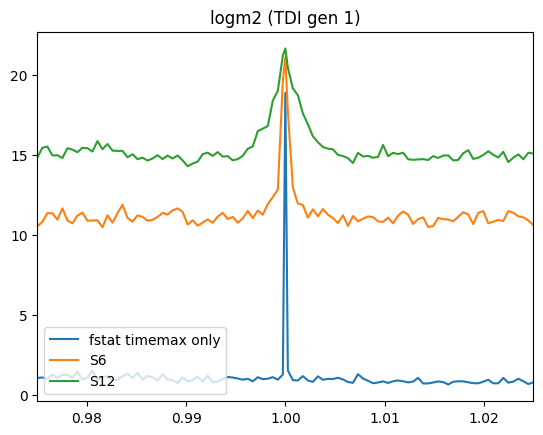

In [46]:
plt.plot(param_range, f_stats_tm,   label='fstat timemax only')
# plt.plot(param_range, f_stats_pm,   label='fstat phasemax only')
# plt.plot(param_range, f_stats_pure, label='fstat pure')
# plt.plot(param_range, f_stats_tmX, label='fstat timemax in X only')
# plt.plot(param_range, X_pure, label='X pure')
# plt.plot(param_range, X_tm, label='X timemax')
# plt.plot(param_range, X_tpm, label='X timemax +phasemax')
# plt.plot(param_range, Sfour, label='S4')
plt.plot(param_range, Ssix, label='S6')
plt.plot(param_range, Stwelve, label='S12')
# plt.plot(param_range, Ssixteen, label='S16')
# plt.plot(param_range, Sp, label='S12 no timemax')

plt.xlim(0.975, 1.025)
plt.title('logm2 (TDI gen 1)')
plt.legend(loc='lower left')
plt.savefig('logden.png', dpi=300, bbox_inches='tight')
plt.show()

In [41]:
# import matplotlib.pyplot as plt
# fig_1d, axs_1d = plt.subplots(1, 5, figsize=(20, 4))
# labels = [r'$\log_{10}(m_1)$', r'$\log_{10}(m_2)$', r'$a$', r'$p_0$', r'$e_0$', r'$T$']
# plt.ylabel('logden', fontsize=12)
# for dim in range(5):
#     ax = axs_1d[dim]

#     # Plot theoretical log-density
#     ax.plot(line_points_proc1[dim], X_sc_line, '-', 
#             color='blue', alpha=0.5, linewidth=2, label='semicoherent')


#     # Mark the max likelihood points
#     ax.axvline(proc1_maxld_pt_1d[dim], color='blue', linestyle='--', 
#                alpha=0.5, label=f'Proc1 Max Logden Point')
#     ax.axvline(param_true[dim], color='red', linestyle='--', 
#                alpha=0.5, label='True Point')
    
#     ax.set_xlabel(labels[dim], fontsize=12)
#     # ax.set_ylabel('logden', fontsize=12)
#     ax.grid(True, alpha=0.3)

# plt.legend()
# plt.tight_layout()


In [42]:
# Generate trajectory to get fundamental frequencies
print("Computing fundamental frequencies...")
from few.trajectory.inspiral import EMRIInspiral
from few.utils.constants import YRSID_SI

N_traj = 5000
delta_T = T*YRSID_SI/5000
traj_gen = EMRIInspiral(func='KerrEccEqFlux')
t_arr, p_arr, e_arr, x_arr, Phi_phi_arr, Phi_theta_arr, Phi_r_arr = traj_gen(
    m1, m2, a, p0, e0, xI0, T=T, dt=dt, upsample=True,
    Phi_phi0=Phi_phi0, Phi_theta0=Phi_theta0, Phi_r0=Phi_r0
)

Computing fundamental frequencies...


In [43]:
from few.utils.utility import get_p_at_t

get_p_at_t(traj_module=traj_gen, t_out=1, traj_args=[m1, m2, a, e0, xI0])


7.688179003044686